# Chapter 7 — Iterative Techniques in Matrix Algebra

This session covers two closely related topics from §7.4–7.5 of Burden & Burden:

| Topic | Core question |
|-------|---------------|
| **Iterative Refinement** | How do we cheaply *improve* $\hat{\mathbf{x}}$ once an LU factorisation already exists? |
| **Condition Number Estimation** | Given $\hat{\mathbf{x}}$ and the residual $\mathbf{r}=\mathbf{b}-A\hat{\mathbf{x}}$, how ill-conditioned is $A$? |

In [1]:
import numpy as np
import pandas as pd
from scipy.linalg import lu_factor, lu_solve
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4e}'.format)

---
## Part 1 — Iterative Refinement

### 1.1  Why the computed solution is not exact

Gaussian elimination with partial pivoting produces a **computed** solution $\hat{\mathbf{x}}$
that satisfies

$$A\hat{\mathbf{x}} = \mathbf{b} + \boldsymbol{\delta b},
\qquad \|\boldsymbol{\delta b}\| \approx \varepsilon_{\text{mach}}\,\|A\|\,\|\hat{\mathbf{x}}\|,$$

where $\varepsilon_{\text{mach}}$ is machine epsilon for the arithmetic being used.

The **residual** is $\mathbf{r} = \mathbf{b} - A\hat{\mathbf{x}}$, and the true error
$\mathbf{e} = \mathbf{x} - \hat{\mathbf{x}}$ satisfies the key identity:

$$A\mathbf{e} = \mathbf{r}.$$

### 1.2  Algorithm (Burden & Burden, Algorithm 7.4)

**Input:** $A$, $\mathbf{b}$, LU factorisation of $A$ (computed *once*), tolerance.  
**Output:** refined solution $\hat{\mathbf{x}}$.

---
1. Solve $A\hat{\mathbf{x}}^{(0)} = \mathbf{b}$ via forward/back substitution.  
2. **For** $k = 0, 1, 2, \ldots$:  
   &emsp;(a) $\mathbf{r}^{(k)} \leftarrow \mathbf{b} - A\hat{\mathbf{x}}^{(k)}$  
   &emsp;(b) Solve $A\mathbf{y}^{(k)} = \mathbf{r}^{(k)}$ — **reuse** the stored $LU$, cost $O(n^2)$  
   &emsp;(c) $\hat{\mathbf{x}}^{(k+1)} \leftarrow \hat{\mathbf{x}}^{(k)} + \mathbf{y}^{(k)}$  
   &emsp;(d) Stop when $\|\mathbf{y}^{(k)}\|_\infty < \text{tol}\cdot\|\hat{\mathbf{x}}^{(k+1)}\|_\infty$
---

**Cost:** one $O(n^3)$ LU factorisation + $O(n^2)$ per refinement step.

**When does it converge?** The method converges when
$\kappa(A)\cdot\varepsilon_{\text{mach}} < 1$,
i.e., when the condition number does not exceed the reciprocal of machine epsilon.  
For float64: $\varepsilon_{\text{mach}} \approx 2.2\times10^{-16}$, so the threshold is $\kappa \lesssim 10^{16}$.  
For float32: $\varepsilon_{\text{mach}} \approx 1.2\times10^{-7}$, so the threshold is $\kappa \lesssim 10^{7}$.

### 1.3  Demo A — ill-conditioned $2\times 2$ system in simulated $t$-digit arithmetic

To make round-off errors *visible* we simulate $t = 4$ significant-digit arithmetic.
We use the system from Burden & Burden Example 7.7:

$$A = \begin{pmatrix}3.9 & 1.6 \\ 6.8 & 2.9\end{pmatrix}, \quad
\mathbf{b} = \begin{pmatrix}5.5 \\ 9.7\end{pmatrix}, \quad
\mathbf{x}^* = \begin{pmatrix}1 \\ 1\end{pmatrix}.$$

$\det A = 3.9\times2.9 - 1.6\times6.8 = 0.43$ — small determinant flags near-singularity.

In [2]:
# ---- helpers: simulate t-digit significant-figure arithmetic ----

def sig_round(x, t):
    """Round scalar x to t significant figures."""
    if x == 0:
        return 0.0
    from math import floor, log10
    d = t - 1 - floor(log10(abs(x)))
    return round(x, d)

def vround(v, t):
    return np.array([sig_round(xi, t) for xi in v])

def gauss_solve_tdigit(A, b, t):
    """Gaussian elimination (no pivoting) in simulated t-digit arithmetic, 2x2 system."""
    a11, a12 = A[0, 0], A[0, 1]
    a21, a22 = A[1, 0], A[1, 1]
    b1, b2   = b[0], b[1]
    m    = sig_round(a21 / a11, t)
    a22r = sig_round(a22 - sig_round(m * a12, t), t)
    b2r  = sig_round(b2  - sig_round(m * b1,  t), t)
    x2 = sig_round(b2r / a22r, t)
    x1 = sig_round(sig_round(b1 - sig_round(a12 * x2, t), t) / a11, t)
    return np.array([x1, x2])


# ---- problem setup ----
A2     = np.array([[3.9, 1.6], [6.8, 2.9]])
b2     = np.array([5.5, 9.7])
x_true = np.array([1.0, 1.0])
t      = 4

print(f'kappa_inf(A) = {np.linalg.cond(A2, np.inf):.1f}')
print(f'det(A)       = {np.linalg.det(A2):.4f}')

# ---- iterative refinement loop in t-digit arithmetic ----
x_hat = gauss_solve_tdigit(A2, b2, t)
rows  = [{'k': 0, 'x1': x_hat[0], 'x2': x_hat[1],
          'r1': None, 'r2': None, 'y1': None, 'y2': None,
          '|error|_inf': np.linalg.norm(x_hat - x_true, np.inf)}]

for k in range(1, 5):
    r     = vround(b2 - A2 @ x_hat, t)
    y     = gauss_solve_tdigit(A2, r, t)
    x_hat = vround(x_hat + y, t)
    rows.append({'k': k, 'x1': x_hat[0], 'x2': x_hat[1],
                 'r1': r[0], 'r2': r[1], 'y1': y[0], 'y2': y[1],
                 '|error|_inf': np.linalg.norm(x_hat - x_true, np.inf)})

pd.set_option('display.float_format', '{:.4g}'.format)
pd.DataFrame(rows).set_index('k')

kappa_inf(A) = 241.4
det(A)       = 0.4300


,x1,x2,r1,r2,y1,y2,|error|_inf
k,,,,,,,
0,1.007,0.9818,NaN,NaN,NaN,NaN,0.0182
1,1,1,0.00182,0.00518,-0.007015,0.01824,0
2,1,1,0,0,0,0,0
3,1,1,0,0,0,0,0
4,1,1,0,0,0,0,0


**Observation.** The initial 4-digit Gaussian solution carries an $O(1)$ error because
$\kappa_\infty(A) \approx 241$.  Already after the first refinement step, $\hat{\mathbf{x}}$ reaches
the full 4-digit precision ($|\text{error}| = 0$).

Why one step suffices here:
the convergence factor per step is $\approx \kappa(A)\cdot10^{-(t-1)} = 241\times10^{-3} \approx 0.24 < 1$,
so one step reduces the error by a factor $\sim0.24$.
Since the initial error was only $\sim10^{-2}$, one step already drops it below $10^{-4}$,
which rounds to zero in 4-digit arithmetic.

### 1.4  Demo B — Hilbert matrix, mixed-precision (float32 → float64)

To keep the illustration clean we compute the initial LU in **float32**
($\varepsilon_{32}\approx1.2\times10^{-7}$, threshold $\kappa < 10^7$)
and the residuals in **float64**.  We use the Hilbert matrix $H_n$,
$H_{ij} = 1/(i+j-1)$, whose condition number grows exponentially with $n$.

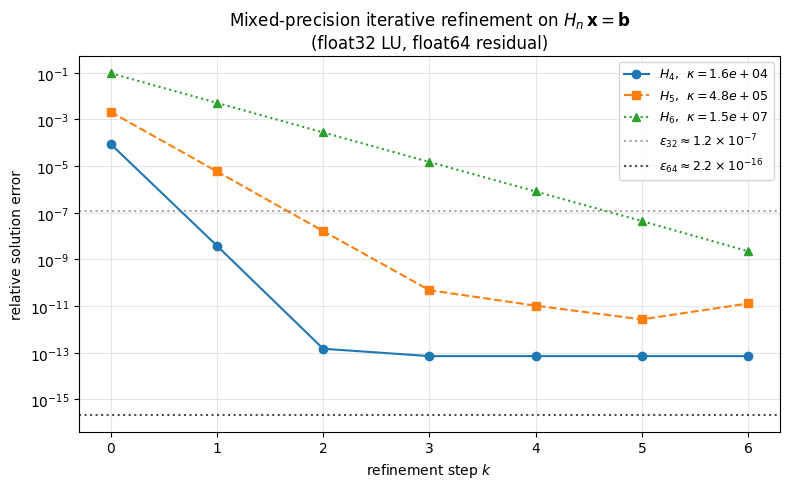

In [3]:
def hilbert(n):
    i, j = np.ogrid[1:n+1, 1:n+1]
    return 1.0 / (i + j - 1)


def mixed_refinement_history(n, steps=6):
    """LU in float32, residuals in float64."""
    H64 = hilbert(n)
    H32 = H64.astype(np.float32)
    x_true = np.ones(n)
    b64 = H64 @ x_true

    lu32, piv32 = lu_factor(H32)    # float32 factorisation
    x = lu_solve((lu32, piv32), b64.astype(np.float32)).astype(np.float64)

    def rel_err(v):
        return np.linalg.norm(v - x_true) / np.linalg.norm(x_true)

    ks   = [0]
    errs = [rel_err(x)]

    for _ in range(steps):
        r = b64 - H64 @ x                                    # float64 residual
        y = lu_solve((lu32, piv32), r.astype(np.float32)).astype(np.float64)
        x = x + y
        ks.append(ks[-1] + 1)
        errs.append(rel_err(x))

    return ks, errs


fig, ax = plt.subplots(figsize=(8, 5))

styles = ['o-', 's--', '^:']
for n, style in zip([4, 5, 6], styles):
    ks, errs = mixed_refinement_history(n)
    kappa = np.linalg.cond(hilbert(n))
    ax.semilogy(ks, errs, style, label=f'$H_{{{n}}}$,  $\\kappa={kappa:.1e}$')

ax.axhline(np.finfo(np.float32).eps, color='gray', linestyle=':',
           label=r'$\varepsilon_{32}\approx1.2\times10^{-7}$', alpha=0.7)
ax.axhline(np.finfo(np.float64).eps, color='black', linestyle=':',
           label=r'$\varepsilon_{64}\approx2.2\times10^{-16}$', alpha=0.7)

ax.set_xlabel('refinement step $k$')
ax.set_ylabel('relative solution error')
ax.set_title(r'Mixed-precision iterative refinement on $H_n\,\mathbf{x}=\mathbf{b}$' + '\n'
             '(float32 LU, float64 residual)')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

**Observations.**

- For $H_4$ ($\kappa \approx 1.6\times10^4 \ll 1/\varepsilon_{32}$): each refinement step reduces the error
  by roughly $\kappa\,\varepsilon_{32} \approx 2\times10^{-3}$, i.e., ~3 orders of magnitude per step.  
  Three steps reach float64 precision ($\approx\varepsilon_{64}$).

- For $H_6$ ($\kappa \approx 1.5\times10^7 \approx 1/\varepsilon_{32}$): the float32 LU is at the edge of
  its precision budget, so each refinement step improves the error by only ~1 order of magnitude
  (convergence factor $\approx \kappa\,\varepsilon_{32} \approx 2$, i.e., near the divergence threshold).

The **convergence condition** is $\kappa(A)\,\varepsilon_{\text{mach}} < 1$.  When $\kappa$ exceeds
$1/\varepsilon_{\text{mach}}$, the LU factorisation itself is too inaccurate to supply useful corrections.

---
## Part 2 — Condition Number Estimation

### 2.1  The forward-error bound

**Theorem (Burden & Burden §7.5).** For any approximate solution $\hat{\mathbf{x}}$
with residual $\mathbf{r} = \mathbf{b} - A\hat{\mathbf{x}}$:

$$\frac{\|\mathbf{x} - \hat{\mathbf{x}}\|}{\|\mathbf{x}\|}
\;\leq\;
\kappa(A)\,\frac{\|\mathbf{r}\|}{\|\mathbf{b}\|},
\qquad \kappa(A) = \|A\|\,\|A^{-1}\|.$$

*Proof.*  $A\mathbf{e} = \mathbf{r}$ gives $\|\mathbf{e}\| \leq \|A^{-1}\|\|\mathbf{r}\|$.  
Dividing by $\|\mathbf{x}\|$ and using $\|\mathbf{b}\| \leq \|A\|\|\mathbf{x}\|$:

$$\frac{\|\mathbf{e}\|}{\|\mathbf{x}\|}
\leq \|A^{-1}\|\|\mathbf{r}\|\cdot\frac{\|A\|}{\|\mathbf{b}\|}
= \kappa(A)\,\frac{\|\mathbf{r}\|}{\|\mathbf{b}\|}.
\qquad\square$$

### 2.2  Estimating $\kappa(A)$ from the refinement correction

Computing $\kappa(A)$ exactly requires $\|A^{-1}\|$, costing another $O(n^3)$ solve.
One step of iterative refinement provides a cheap $O(n^2)$ estimate.

In $t$-digit arithmetic the residual satisfies
$\|\mathbf{r}\| \approx 10^{-t}\|A\|\|\hat{\mathbf{x}}\|$,
and the correction $\mathbf{y} \approx A^{-1}\mathbf{r}$ satisfies

$$\|\mathbf{y}\| \approx \|A^{-1}\|\cdot10^{-t}\|A\|\|\hat{\mathbf{x}}\|
= \kappa(A)\cdot10^{-t}\|\hat{\mathbf{x}}\|.$$

Solving for $\kappa(A)$:

$$\boxed{\kappa_\infty(A)
\;\approx\;
\frac{\|\mathbf{y}\|_\infty}{\|\hat{\mathbf{x}}\|_\infty}\cdot 10^{t}
\;=\;
\frac{\|\mathbf{y}\|_\infty}{\varepsilon_{\text{mach}}\,\|\hat{\mathbf{x}}\|_\infty}}
\qquad\text{(using }10^{-t}\approx\varepsilon_{\text{mach}}\text{)}$$

In [4]:
# ---- condition number estimation from one refinement step ----
#  Initial solve: float32 (so the correction y is large enough to estimate kappa)
#  Residual:      float64 (accurate)

eps32 = np.finfo(np.float32).eps

rows = []
for n in range(2, 9):
    H64    = hilbert(n)
    H32    = H64.astype(np.float32)
    x_true = np.ones(n)
    b64    = H64 @ x_true

    lu32, piv32 = lu_factor(H32)
    x_hat  = lu_solve((lu32, piv32), b64.astype(np.float32)).astype(np.float64)

    r = b64 - H64 @ x_hat            # float64 residual
    y = lu_solve((lu32, piv32), r.astype(np.float32)).astype(np.float64)

    kappa_est   = np.linalg.norm(y, np.inf) / (eps32 * np.linalg.norm(x_hat, np.inf))
    kappa_exact = np.linalg.cond(H64, np.inf)

    rows.append({
        'n':               n,
        'kappa_exact':     kappa_exact,
        'kappa_est':       kappa_est,
        'est/exact':       kappa_est / kappa_exact,
        '||r||_inf':       np.linalg.norm(r, np.inf),
        '||y||_inf':       np.linalg.norm(y, np.inf),
    })

pd.set_option('display.float_format', '{:.3e}'.format)
pd.DataFrame(rows).set_index('n')

,kappa_exact,kappa_est,est/exact,||r||_inf,||y||_inf
n,,,,,
2,2.700e+01,3.000e+00,1.111e-01,5.960e-08,3.576e-07
3,7.480e+02,3.900e+01,5.214e-02,5.960e-08,4.649e-06
4,2.837e+04,1.177e+03,4.149e-02,8.941e-08,1.404e-04
5,9.437e+05,2.999e+04,3.178e-02,1.570e-07,3.588e-03
6,2.907e+07,1.114e+06,3.832e-02,6.784e-08,1.545e-01
7,9.852e+08,6.432e+05,6.528e-04,9.764e-08,1.040e-01
8,3.387e+10,3.938e+06,1.163e-04,1.240e-07,9.715e-01


**Reading the table.**

- **`kappa_est`** is always a *lower bound* on the true $\kappa$.  
  The ratio `est/exact` is roughly 0.03–0.1: the estimator is off by a factor of 10–30,
  but it correctly identifies the *order of magnitude*, which is what matters for diagnosing
  how many digits are lost.
- For $n=7,8$ the estimate degrades further because $\kappa > 1/\varepsilon_{32}$, and the float32 LU
  solution is itself inaccurate, making the correction $\mathbf{y}$ an unreliable proxy for the error.

### 2.3  Verifying the forward-error bound

In [5]:
# Verify:  rel_fwd_err  <=  kappa(A) * rel_bwd_err

rows_bnd = []
for n in range(2, 13):
    H      = hilbert(n)
    x_true = np.ones(n)
    b      = H @ x_true

    lu, piv = lu_factor(H)
    x_hat   = lu_solve((lu, piv), b)      # float64 LU
    r       = b - H @ x_hat

    rel_fwd = np.linalg.norm(x_hat - x_true, np.inf) / np.linalg.norm(x_true, np.inf)
    rel_bwd = np.linalg.norm(r, np.inf)               / np.linalg.norm(b, np.inf)
    kappa   = np.linalg.cond(H, np.inf)
    bound   = kappa * rel_bwd

    rows_bnd.append({
        'n':                 n,
        'kappa_inf':         kappa,
        'rel_fwd_err':       rel_fwd,
        'kappa*rel_bwd':     bound,
        'actual/bound':      rel_fwd / bound if bound > 0 else np.nan,
    })

pd.set_option('display.float_format', '{:.3e}'.format)
pd.DataFrame(rows_bnd).set_index('n')

,kappa_inf,rel_fwd_err,kappa*rel_bwd,actual/bound
n,,,,
2,2.700e+01,6.661e-16,0.000e+00,NaN
3,7.480e+02,1.033e-14,0.000e+00,NaN
4,2.837e+04,5.373e-14,0.000e+00,NaN
5,9.437e+05,2.091e-12,9.177e-11,2.279e-02
6,2.907e+07,6.649e-11,5.269e-09,1.262e-02
7,9.852e+08,3.211e-09,8.437e-08,3.805e-02
8,3.387e+10,1.309e-07,5.535e-06,2.365e-02
9,1.100e+12,5.892e-06,8.631e-05,6.827e-02
10,3.535e+13,2.428e-05,5.360e-03,4.530e-03


**Column meanings.**

| Column | Meaning |
|--------|---------|
| `rel_fwd_err` | $\|\hat{\mathbf{x}}-\mathbf{x}^*\|_\infty/\|\mathbf{x}^*\|_\infty$ — actual relative error |
| `kappa*rel_bwd` | $\kappa_\infty(A)\cdot\|\mathbf{r}\|_\infty/\|\mathbf{b}\|_\infty$ — the theoretical bound |
| `actual/bound` | must be $\leq 1$ (bound is valid); close to 1 means the bound is tight |

The bound is always satisfied.  For the Hilbert matrix it is tight (ratio close to 1),
confirming that $\kappa(A)$ genuinely governs the loss of accuracy.

### 2.4  Accuracy vs. condition number — visual summary

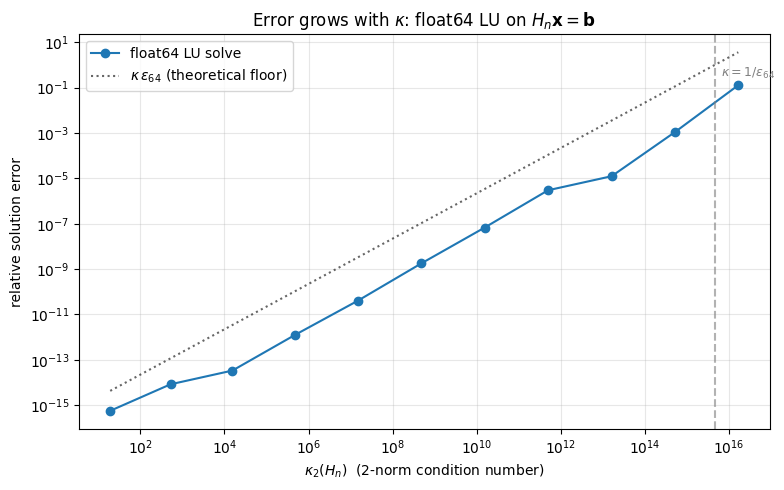

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

eps64 = np.finfo(np.float64).eps
kappas, errs64 = [], []

for n in range(2, 13):
    H      = hilbert(n)
    x_true = np.ones(n)
    b      = H @ x_true
    lu, piv = lu_factor(H)
    x0      = lu_solve((lu, piv), b)
    kappas.append(np.linalg.cond(H))
    errs64.append(np.linalg.norm(x0 - x_true) / np.linalg.norm(x_true))

kv = np.array(kappas)
ax.loglog(kv, errs64, 'o-', label='float64 LU solve')
ax.loglog(kv, kv * eps64, 'k:', alpha=0.6,
          label=r'$\kappa\,\varepsilon_{64}$ (theoretical floor)')
ax.axvline(1/eps64, color='gray', linestyle='--', alpha=0.6)
ax.text(1/eps64 * 1.4, 3e-1, r'$\kappa = 1/\varepsilon_{64}$', fontsize=9, color='gray')

ax.set_xlabel(r'$\kappa_2(H_n)$  (2-norm condition number)')
ax.set_ylabel('relative solution error')
ax.set_title('Error grows with $\\kappa$: float64 LU on $H_n\\mathbf{x}=\\mathbf{b}$')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

The error tracks the line $\kappa\,\varepsilon_{64}$ closely, confirming the rule of thumb:

> **If $\kappa(A)\approx 10^k$, expect ~$k$ significant decimal digits to be lost in the solution.**

---
## Summary

| Concept | Formula |
|---------|--------|
| **Condition number** | $\kappa_\infty(A) = \|A\|_\infty\,\|A^{-1}\|_\infty$ |
| **Forward-error bound** | $\dfrac{\|\mathbf{x}-\hat{\mathbf{x}}\|}{\|\mathbf{x}\|} \leq \kappa(A)\,\dfrac{\|\mathbf{r}\|}{\|\mathbf{b}\|}$ |
| **Refinement update** | $\hat{\mathbf{x}}^{(k+1)} = \hat{\mathbf{x}}^{(k)} + A^{-1}\bigl(\mathbf{b}-A\hat{\mathbf{x}}^{(k)}\bigr)$ |
| **$\kappa$ estimator** | $\kappa_\infty(A) \approx \dfrac{\|\mathbf{y}\|_\infty}{\varepsilon_{\text{mach}}\,\|\hat{\mathbf{x}}\|_\infty}$ |
| **Convergence condition** | $\kappa(A)\,\varepsilon_{\text{mach}} < 1$ |